In [ ]:
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score


print("Loading Training Data...")
train_df = pd.read_csv('training_2022_fixed.csv')
print(f"Rows before dropna: {len(train_df)}")
train_df = train_df.dropna()
print(f"Rows after dropna: {len(train_df)}")

if len(train_df) == 0:
    print("Error: No data remains after removing missing values. Please check your CSV file.")
else:

    y = train_df['class'].values

    X_df = train_df.drop(['class', 'id', 'xcoord', 'ycoord'], axis=1, errors='ignore')
    X_train_feat = X_df.values
    print(f"Feature columns: {list(X_df.columns)}")


    if len(X_train_feat) > 1:
        X_tr, X_te, y_tr, y_te = train_test_split(X_train_feat, y, test_size=0.2, random_state=42)

        print("Training the Random Forest Classifier...")
        clf = RandomForestClassifier(n_estimators=100, random_state=42)
        clf.fit(X_tr, y_tr)


        print("\n--- MODEL ACCURACY ---")
        print(f'Overall Accuracy (OA): {accuracy_score(y_te, clf.predict(X_te)):.2%}')


        band_names = X_df.columns.tolist()
        importances = pd.Series(clf.feature_importances_, index=band_names)
        plt.figure(figsize=(8, 5))
        importances.sort_values().plot.barh(color='teal')
        plt.title('Band Importance')
        plt.tight_layout()
        plt.show()


        print("\nPredicting the whole map...")
        with rasterio.open('Stacked_2022.tif') as src:
            img = src.read()
            out_meta = src.meta.copy()
            bands, h, w = img.shape
            img_2d = img.reshape(bands, -1).T
            img_2d = np.nan_to_num(img_2d)
            pred_2d = clf.predict(img_2d)
            pred_img = pred_2d.reshape(h, w)

        out_meta.update({"count": 1, "dtype": "uint8"})
        with rasterio.open('LULC_FINAL_2022.tif', 'w', **out_meta) as dest:
            dest.write(pred_img.astype(np.uint8), 1)
        print("Saved: LULC_FINAL_2022.tif")
    else:
        print("Error: Not enough samples to split into train and test sets.")

Loading Training Data...
Initial rows: 168

Missing values per column:
id          168
class         1
SAMPLE_1      0
SAMPLE_2      0
SAMPLE_3      0
dtype: int64
Rows after dropping missing labels: 167
Feature columns being used: ['SAMPLE_1', 'SAMPLE_2', 'SAMPLE_3']
Training the Random Forest Classifier...
Overall Accuracy (OA): 100.00%

Predicting the whole map...
Saved: LULC_FINAL_2022.tif


Saved: feature_importance.png


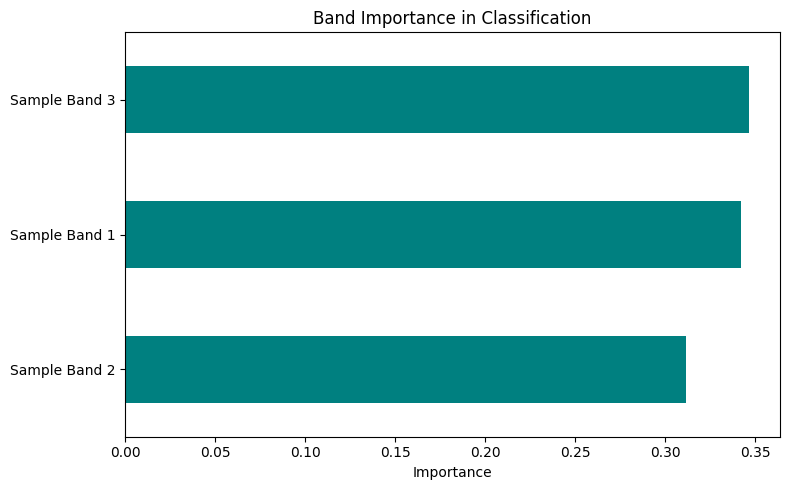

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(clf.feature_importances_, index=['Sample Band 1', 'Sample Band 2', 'Sample Band 3'])

plt.figure(figsize=(8, 5))
importances.sort_values().plot.barh(color='teal')
plt.title('Band Importance in Classification')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
print("Saved: feature_importance.png")
plt.show()